# Item Effectiveness in Deadlock

The game Deadlock is a characters based 6v6 game where the objective is to defeat opponents and destroy their base. Each player accrues resources through these objectives and uses that income to purchase items. Deadlock's item system is very robust and intentionally provides items that counter specific traits that are common among characters. Characters that are mainly use abilities can be silenced, characters that mainly use their weapon can be disabled and so on. 

This project aims to investigate 5 specific characters and community perceived counter items. We'll look at the following:

| Archetype | Character | Item |
|----------|----------|----------|
| High Mobility | Mina | Slowing Hex | 
| Debuff / Damage over time | Infernus | Dispel Magic | 
| Channeled ability | Dynamo | Knockdown |
| Weapon | Vyper | Metal Skin | 
| Weapon | Haze | Disarming Hex |

Two chi squares are dedicated to weapon as I walso want to investigate the difference between offensive counter items (Disarming Hex) and reactive counter items (Metal Skin).

Dataset consists of 200k matches from the past 6 months with around 15k matches deemed high rank, sampled randomly over the course of said time. We will use a concentrated dataset of high rank players only for this portion, as counter items inherently have a more pronounced effect at lower ranks, where misplays are less punished. 

If time allows, an investigation of all items against all characters will calculated and composed into a volcano graph to see if there are items that have a distinct negative impact on a player's interaction with a character as an opponent. 


Polars to be used for 

In [5]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency

hero_item_map = {
    "Mina":     np.uint32(1813726886),
    "Infernus": np.uint32(3731635960),
    "Vyper":    np.uint32(1378931225),
    "Dynamo":   np.uint32(1254091416),
    "Haze":     np.uint32(2061878743)
}

SKILL_CUTS     = {'low': (0, 99), 'high': (100, 9999)}
OTHER_TEAM     = {'Team0': 'Team1', 'Team1': 'Team0'}



In [6]:
items_lookup = pd.read_parquet('data/public_items.parquet')
heroes_lookup = pd.read_parquet('data/public_heroes.parquet')

hero_id_map = {}

for col in items_lookup.columns:
    items_lookup[col] = items_lookup[col].apply(lambda x: x.decode() if isinstance(x, bytes) else x)

upgrade_item_ids = set(items_lookup[items_lookup['type'] == 'upgrade']['id'])
item_id_to_name  = items_lookup.set_index('id')['name'].to_dict()
hero_id_to_name  = heroes_lookup.set_index('id')['name'].to_dict()

for hero in hero_item_map.keys():
    hero_id_map[hero] = heroes_lookup[heroes_lookup['name'] == hero]['id'].iloc[0]

In [9]:
import os 

DATA_FILES       = ['data/collected_matches.jsonl']
HIGH_RANK_BADGE  = 100   # avg_badge >= 100 on BOTH teams → high-rank match

player_rows = []
item_rows = []

for path in DATA_FILES:
    if not os.path.exists(path):
        print(f" {path} not found")
        continue
    with open(path) as f:
        for line in f:
            try:
                match = json.loads(line)
            except json.JSONDecodeError:
                continue
            if match['average_badge_team0'] < HIGH_RANK_BADGE or match['average_badge_team1'] < HIGH_RANK_BADGE:
                continue
            mid = match['match_id']
            won = match['winning_team']
            for player in match['players']:
                team = player['team']
                player_rows.append({'match_id':mid, 'team': team, 'hero_id': player['hero_id'], 'won': int(team == won)})
                for item in player['items']:
                    iid = np.uint32(item['item_id'])
                    if iid not in upgrade_item_ids:
                        continue
                    item_rows.append({'match_id': mid, 'team': team, 'hero_id': player['hero_id'],
                                      'won': int(team == won), 'item_id': iid,
                                      'held':     item['sold_time_s'] == 0,
                                      'was_sold': item['sold_time_s'] >  0})

players_df = pd.DataFrame(player_rows)
players_df['hero_name'] = players_df['hero_id'].map(hero_id_to_name)

items_df = pd.DataFrame(item_rows)
items_df['item_name'] = items_df['item_id'].map(item_id_to_name)

## 1. Hold Rate and Win Rate

For each item/hero combination, how effective is the item actually? 

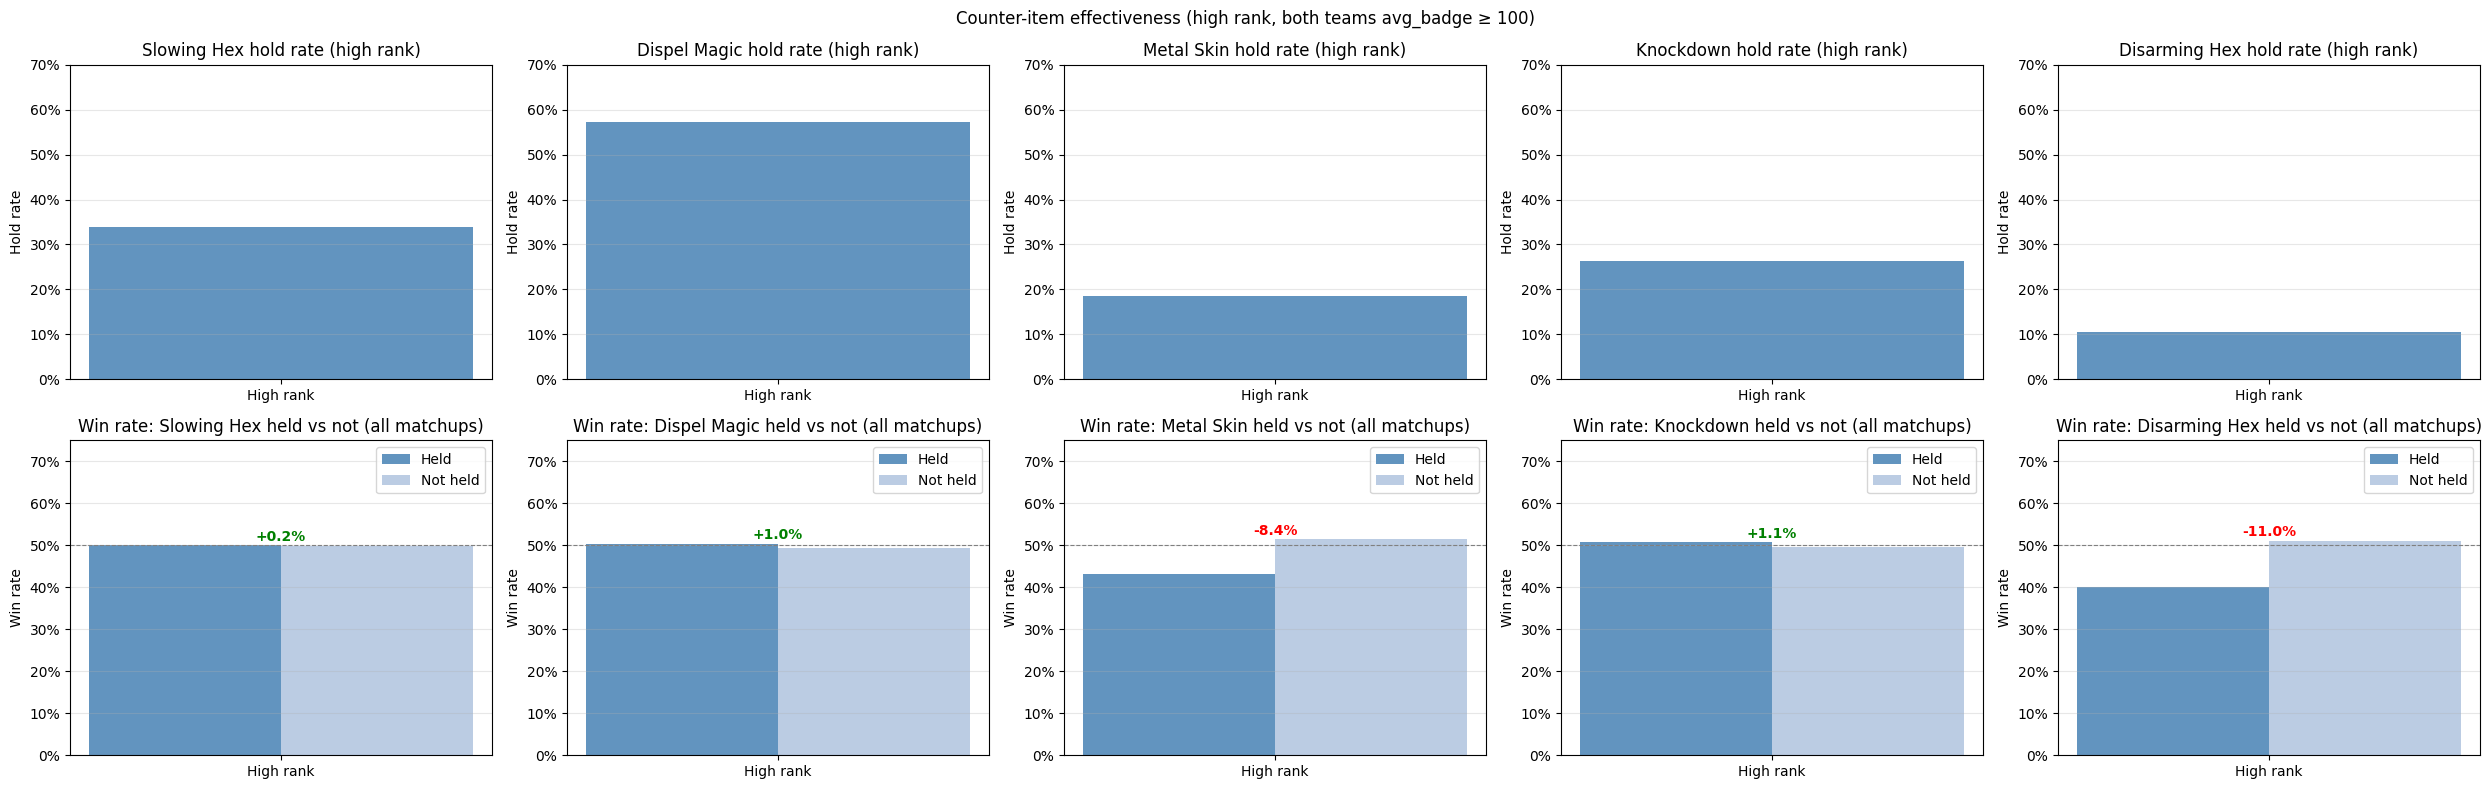

In [22]:
outcomes = players_df[['match_id', 'team', 'won']].drop_duplicates()

fig, axes = plt.subplots(2, len(hero_item_map), figsize=(5 * len(hero_item_map), 8))

for i, (hero, item_id) in enumerate(hero_item_map.items()):
    item_held = (
        items_df[(items_df['item_id'] == item_id) & items_df['held']]
        [['match_id', 'team']]
        .drop_duplicates()
        .assign(held_item=1)
    )

    team_df = outcomes.merge(item_held, on=['match_id', 'team'], how='left')
    team_df['held_item'] = team_df['held_item'].fillna(0).astype(int)

    held      = team_df[team_df['held_item'] == 1]['won']
    not_held  = team_df[team_df['held_item'] == 0]['won']
    hold_rate = team_df['held_item'].mean()
    delta     = held.mean() - not_held.mean()
    item_name = item_id_to_name[item_id]

    ax0, ax1 = axes[0, i], axes[1, i]

    ax0.bar(['High rank'], [hold_rate], color='steelblue', alpha=0.85)
    ax0.set_ylabel('Hold rate')
    ax0.set_title(f'{item_name} hold rate (high rank)')
    ax0.yaxis.set_major_formatter('{x:.0%}')
    ax0.set_ylim(0, 0.7)
    ax0.grid(axis='y', alpha=0.3)

    w, x = 0.35, np.array([0])
    ax1.bar(x - w/2, [held.mean()],     w, label='Held',     color='steelblue',      alpha=0.85)
    ax1.bar(x + w/2, [not_held.mean()], w, label='Not held', color='lightsteelblue', alpha=0.85)
    ax1.annotate(f'{delta:+.1%}',
                 xy=(0, max(held.mean(), not_held.mean()) + 0.01),
                 ha='center', fontsize=10, color='green' if delta > 0 else 'red', fontweight='bold')
    ax1.axhline(0.5, color='grey', linewidth=0.8, linestyle='--')
    ax1.set_xticks(x); ax1.set_xticklabels(['High rank'])
    ax1.set_ylim(0, 0.75); ax1.set_ylabel('Win rate')
    ax1.set_title(f'Win rate: {item_name} held vs not (all matchups)')
    ax1.yaxis.set_major_formatter('{x:.0%}')
    ax1.legend(); ax1.grid(axis='y', alpha=0.3)

plt.suptitle('Counter-item effectiveness (high rank, both teams avg_badge ≥ 100)', fontsize=12)
plt.tight_layout()
plt.show()